<a href="https://colab.research.google.com/github/nmhom/MAT-422/blob/main/MAT422_HW_3.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.4 Logistic Regression

In [20]:
import numpy as np
import matplotlib.pyplot as plt


## Logistic Regression:
A supervised learning method used to predict the probability that an observation belongs to one of two classes.

For input features $\alpha \in \mathbb{R}^d$, logistic regression models the probability of class 1 as

$$p(\alpha;x) = \sigma(\alpha^T x),$$

where $x$ is the vector of model parameters and $\sigma$ is the sigmoid function: $$\sigma(t) = \frac{1}{1 + e^{-t}}.$$

It maps any real number to a value between 0 and 1, allowing its output to represent a probability.

### Logit Function

Logistic regression starts by saying the log-odds of the probabilities is a linear function of the features:

$$\log\frac{p(\alpha;x)}{1-p(\alpha;x)} = \alpha^T x$$

The left side is called the logit. The plot shows that as $p$ goes from 0 to 1, the logit goes from $-\infty$ to $\infty$. So it turns a probability into any real number, which is why we can set it equal to $\alpha^T x$.

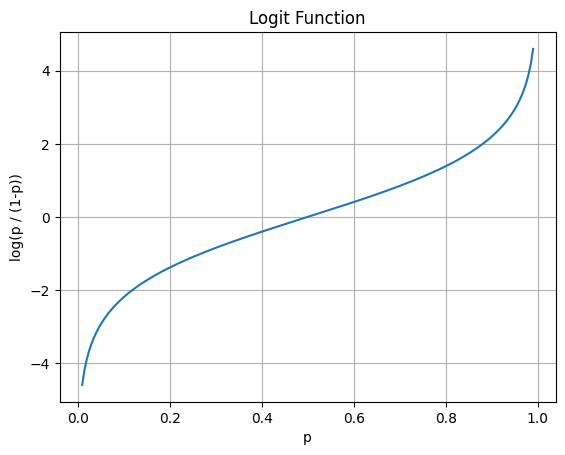

In [14]:
p = np.linspace(0.01, 0.99, 200)
plt.plot(p, np.log(p / (1-p)))
plt.xlabel("p")
plt.ylabel("log(p / (1-p))")
plt.title("Logit Function")
plt.grid()
plt.show()

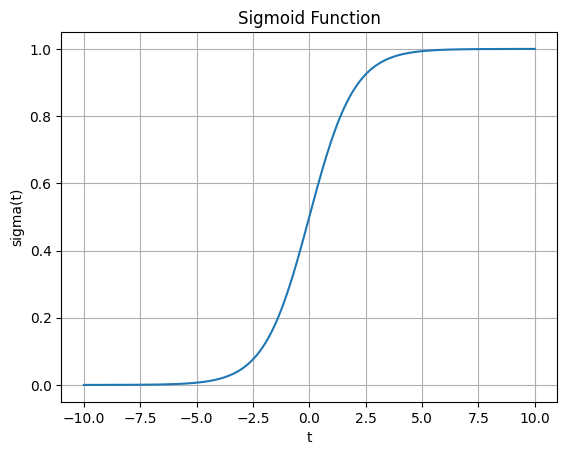

In [15]:
def sigmoid(t):
  return 1 / (1 + np.exp(-t))

t = np.linspace(-10, 10, 200)

plt.plot(t, sigmoid(t))
plt.xlabel('t')
plt.ylabel('sigma(t)')
plt.title("Sigmoid Function")
plt.grid()
plt.show()

If we solve the logit equation for $p$, we get the sigmoid function. The sigmoid does the opposite of the logit: it takes any real number and squishes it to a value between 0 and 1. At $t = 0$, the output is exactly 0.5.

### Derivative of the Sigmoid

The derivative of the sigmoid can be written using the sigmoid itself:

$$\sigma'(t) = \sigma(t)(1-\sigma(t))$$

To check this, the derivative was computed numerically (using a small step $h$) and compared to the formula. The two rows match, so the formula is correct. This formula is what makes the gradient of the loss simple.

In [16]:
t = np.linspace(-5, 5, 5)
h = 1e-5
numerical = (sigmoid(t + h) - sigmoid(t-h)) / (2*h)
formula = sigmoid(t) * (1-sigmoid(t))
print("Numerical derivative:", numerical)
print("sigma(t)(1-sigma(t)):", formula)

Numerical derivative: [0.00664806 0.07010372 0.25       0.07010372 0.00664806]
sigma(t)(1-sigma(t)): [0.00664806 0.07010372 0.25       0.07010372 0.00664806]


### Gradient of the Cross-Entropy Loss

For logistic regression, the gradient of the cross-entropy loss is

$$\nabla\phi(x) = -\frac{1}{n} \sum_{i=1}^{n} (b_i-\sigma(\alpha_i^T x))\alpha_i.$$

The gradient gives the direction in which the loss increases most rapidly. Gradient descent therefore moves in the opposite direction to reduce the loss.

### Example: Hours studied vs. passing

To test logistic regression, a small data set was made where the feature is hours studied and the label is 1 if the student passed and 0 if they failed.

A column was added of ones to $A$ so the model has an intercept. The model then has two parameters: $x_0$ (intercept) and $x_1$ (the slope for hours).

The loss being minimized is the cross-entropy loss.

Learned parameters: [-5.67648623  1.32236696]


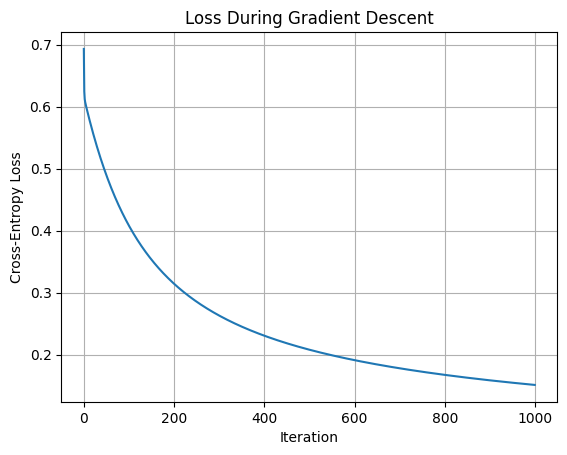

In [17]:
hours = np.array([1,2,3,4,5,6,7,8], dtype=float)
b = np.array([0,0,0,0,1,1,1,1], dtype=float)

# intercept
A = np.column_stack((np.ones(len(hours)), hours))

# starting parameters
x = np.zeros(2)

# Step size
beta = 0.1
losses = []

# run 1000 steps and save the loss each time
for _ in range(1000):
  probabilities = sigmoid(A @ x)

  loss = -np.mean(
      b * np.log(probabilities + 1e-10)
      + (1 - b) * np.log(1 -probabilities + 1e-10)
  )
  losses.append(loss)

  gradient = -(1 / len(b)) * A.T @ (b-probabilities)
  x = x - beta * gradient

print("Learned parameters:", x)

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("Loss During Gradient Descent")
plt.grid()
plt.show()

The loss goes down quickly at first and then levels off. This shows gradient descent is reducing the loss each step.

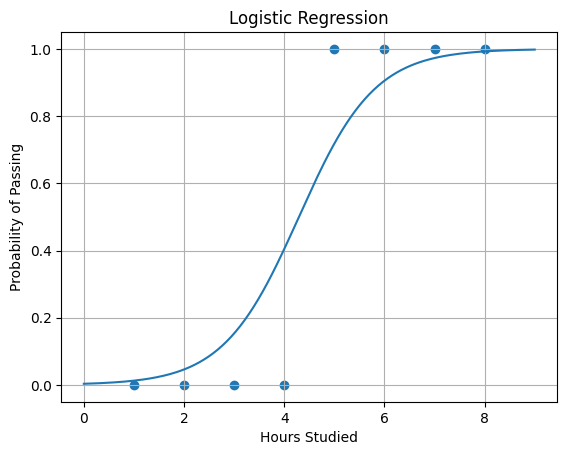

In [18]:
hours_plot = np.linspace(0, 9, 200)

A_plot = np.column_stack((
    np.ones(len(hours_plot)),
    hours_plot
))

probability = sigmoid(A_plot @ x)

plt.scatter(hours, b)
plt.plot(hours_plot, probability)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression")
plt.grid()
plt.show()

The curve shows the prediceted probability of passing for each number of hours. The model predicts students who study more than about 4.3 hours will pass. This matches the data, since everyone with 4 hours or less failed and everyone with 5 or more passed.

### Hessian of the Loss

The Hessian of the cross-entropy loss is:
$$\nabla^2\ell(x) = \frac{1}{n}\sum_{i=1}^{n}\sigma(\alpha_i^T x)\big(1-\sigma(\alpha_i^T x)\big)\,\alpha_i\alpha_i^T$$

I computed it at the parameters I learned and found its eigenvalues:

In [19]:
# hessian = (1/n) * sum of sigma(1 - sigma) * a_i a_i^T
probabilities = sigmoid(A @ x)
weights = probabilities * (1 - probabilities)
H = (A.T * weights) @ A / len(b)

print("Hessian at learned X:")
print(H)
print("Eigenvalues:", np.linalg.eigvals(H))

Hessian at learned X:
[[0.09361002 0.40283172]
 [0.40283172 1.88963605]]
Eigenvalues: [0.00739706 1.97584901]


### Note on Convexity

Both eigenvalues of the Hessian are positive (about 0.007 and 1.98), so the Hessian is positive semidefinite here. This is true for any $x$, since each term in the sum is a nonnegative number times $\alpha_i\alpha_i^T$, which is always PSD. By Lemma 3.3.16, this means the cross-entropy loss is convex, so any local minimum gradient descent finds is also a global minimum.

### Stochastic Gradient Descent

Stochastic gradient descent (SGD) is a faster version of gradient descent. Instead of using all the data points to compute the gradient, it picks one point $I$ at random each step: $$x_{k+1} = x_k + \beta\,\big(b_I - \sigma(\alpha_I^T x_k)\big)\,\alpha_I$$
Each step is much cheaper, which helps with big datasets, but the steps are noisier.

In [21]:
rng = np.random.default_rng(0)
x_sgd = np.zeros(2)
beta = 0.1

for _ in range(5000):
  i = rng.integers(len(b))
  x_sgd = x_sgd + beta * (b[i] - sigmoid(A[i] @ x_sgd)) * A[i]

print("SGD parameters:", x_sgd)
print("Gradient descent parameters:", x)

SGD parameters: [-11.30715719   2.58141201]
Gradient descent parameters: [-5.67648623  1.32236696]


The SGD parameters are bigger, but both models cross 0.5 at about 4.3–4.4 hours, so they make the same predictions. The numbers differ because my data is perfectly separated, so the loss keeps decreasing as the parameters grow, and SGD ran more steps (5000 vs. 1000).